In [1]:
import numpy as np

import matplotlib.pyplot as plt
#from scipy.integrate import odeint
#import mpmath as mpmath
#from scipy.optimize import linear_sum_assignment  # Hungarian algorithm 
import scipy

plt.rc('text', usetex=True)

# %matpnlotlib notebook 
%matplotlib inline 

#import Husimi   # Quantum routines
#import Harp     # Classical integration routines
#import importlib  # for reloading routines if you need to edit them

import pickle  # for storing python classes in binary files 

With fixed mu/epsilon, vary sqrt{a epsilon}
vary N
allow phishift 
allow NPpower
allow Deltab
allow iterations 
vary Delta mu

 we look at k=1 frame potential statistic from a sample of unitaries generated with various recipes
then do ks test with the exp distribution.  Most experiments fail the ks test (null hypothesis is rejected!), 
but unitaries with Haar pass it (good check!)  Next we need to try drifting systems to see if they are better.
Prob distributions look good but fail tests. 
Note that is not the same thing as passing a mean test.  These distributions could still be k-designs for low k. 
The ks test is definitive for saying the probabilities distributions are different. Not specifying that they 
have equivalent means. Chances are the means are not the same though as the z values tend to be high. 

In [2]:
froot = 'Drift_01_'

In [25]:
# control case of unitaries, Haar uniformly distributed using scipy's routine
# which is based on F. Mezzadri, “How to generate random matrices from the classical compact groups”, arXiv:math-ph/0609050v2
# arguments:
#  N  dimension of matrices
#  N_u how many matrices to compute
#  seed:  if you want the same random sequence, then pass an integer>0 as the seed 
# returns:
#  a list of random Haar distributed unitary matrices  in a 3d array N_u x N x N
def Ulist_Harr(N,N_u,seed=None):
    
    Ulist = np.zeros((N_u, N,N), dtype = complex)
    if (seed == None):
        for k in range(N_u):
            U = scipy.stats.unitary_group.rvs(N)
            Ulist[k,:,:] = U
    else:
        rs = np.random.RandomState(seed)
        for k in range(N_u):
            U = scipy.stats.unitary_group.rvs(N,random_state=rs)
            Ulist[k,:,:] = U
    return Ulist


# given a list of matrices Ulist
# compute z = |tr (U V^dagger)|^2 for consecutive pairs of them 
# returns a list of z values that is half as long as original list of matrices 
# calls: perrs()
def kone(Ulist):
    N_u = Ulist.shape[0]
    zlist = np.zeros(0)
    for k in range(0,N_u,2):
        #print(k)
        U = np.squeeze(Ulist[k,:,:])
        V = np.squeeze(Ulist[k+1,:,:])
        Vdagger = V.conj().T
        UVdagger = np.matmul(U,Vdagger)
        z = np.abs( np.linalg.trace(UVdagger))**2
        zlist = np.append(zlist,z)
        
    res = perrs(zlist,'kone1')  # computes stats 
    return zlist, res


# print stuff and return a list of stats from a list of trace measured values 
# calls cdf_exp() 
def perrs(zlist,prefix):
    N_z = len(zlist)
    res = scipy.stats.kstest(zlist,cdf_exp);  res_2s = res.pvalue
    print(prefix,"twosided pvalue={:.3f}".format(res.pvalue))
    res = scipy.stats.kstest(zlist,cdf_exp,alternative='less'); res_l = res.pvalue  
    print(prefix,"lower pvalue={:.3f}".format(res.pvalue))
    res = scipy.stats.kstest(zlist,cdf_exp,alternative='greater'); res_g = res.pvalue
    print(prefix,"greater pvalue={:.3f}".format(res.pvalue))
    # If below 0.05 null hyp is rejected and that's bad

    mm = np.mean(zlist); sig = np.std(zlist); std_err = sig/np.sqrt(N_z)
    print(prefix,"mean z ={:.3f} += {:.3f}, std z = {:.2f}".format(mm, std_err, sig ))
    
    z2list = zlist**2  # take the square for computing means k=2
    mm_2 = np.mean(z2list); sig_2 = np.std(z2list); std_err_2 = sig_2/np.sqrt(N_z)
    print(prefix,"mean z2 ={:.3f} += {:.3f}, std z2 = {:.2f}".format(np.mean(z2list), np.std(z2list)/np.sqrt(N_z), np.std(z2list) ))
    print("")
    return np.array([ res_2s, res_l, res_g, mm, std_err, sig, mm_2, std_err_2,sig_2])
    # res_2s is a twosided pvalue, from ks test with exponential distribution 
    # res_l is a lower pvalue
    # rels_g is a greater pvalue
    # mm is the mean
    # std_err is the standard error
    # sig is the standard deviation computed from the sample 
    # mm_2 is the mean of z^2
    # std_err_2 is the standard error of z^2
    # sig_2 is the standard deviation from the sample of z^2

# cummulative probability density distribution for exponential distribution 
def cdf_exp(x):  
    return 1- np.exp(-x)


# only plots one list of cummulative distns
def plt_stuff1(zlist1,tlabel,ofile):
    fig,ax = plt.subplots(1,1,figsize=(3,3),sharex = True,sharey=True,dpi=200)
    plt.subplots_adjust(bottom=0.1,top=0.98,right=0.99,left=0.1,wspace=0,hspace=0)
    ax.hist(zlist1,bins=160,density=True,range=[0,40],cumulative=True,alpha=0.5)  
    #  chop range otherwise you have a large one that screw up the bins
    ax.set_xlim([0,10])
    x1,x2 = ax.get_xlim()
    xlin = np.linspace(0,x2,30)
    ax.plot(xlin,1-np.exp(-1*xlin), '-', label = r'$1-e^{-z}$')  # com distrubution is 1-exponential
    ax.set_ylabel('probability')
    ax.set_xlabel(r'$|\mathrm{tr} (UV^\dagger)|^2$')
    ax.legend(loc='lower right')

    ax.text(0.5,0.5,tlabel,transform=ax.transAxes)
    if (len(ofile)>2):
        plt.savefig(ofile)
    plt.show()  



In [4]:
# take the output of the series of runs we just did and create 
# arrays that we can plot 
#parms_a = np.array([N,N_u,a,b0,eps,mu0,mup0,Delta_mu,Delta_mup,Delta_b,Delta_taushift])
def mkmmlist(Fvals_list):
    NFv = len(Fvals_list)
    mm_list = np.zeros(NFv)
    std_err_mm = np.zeros(NFv)
    mm2_list = np.zeros(NFv)
    std_err_mm2 = np.zeros(NFv)
    for k in range(NFv):  #[ res_2s, res_l, res_g, mm, std_err, sig, mm_2, std_err_2,sig_2 ])
        mm_list[k] = Fvals_list[k].res[3]
        std_err_mm[k] = Fvals_list[k].res[4]
        mm2_list[k] = Fvals_list[k].res[6]
        std_err_mm2[k] = Fvals_list[k].res[7]
    return mm_list,std_err_mm, mm2_list,std_err_mm2

In [5]:
# compute the propagator U across tau = (0 to 2 pi) x nperiods
# allowing time dependent variations of parameters during Trotterization
#  arguments:
#     N      : size of discrete quantum space
#     ntau   : how many Trotterized steps to take per period
#     parms0 = [a,b,eps,mu,mup]      : parameters of classical model, all unitless, all can drift 
#         at tau=0
#     d_parms = the rate of change in these 5 parameters w.r.t tau.  parms = parms0 + tau*d_parms
#     tau0   : new parameter to shift relative phase of perturbations at tau=0
#     nperiods:  how many periods to drift 
#  returns:
#    Ufinal  : The n period propagator hat U_T  (NxN complex matrix)
#    w       : vector of eigenvalues of U_T in order of increasing phase 
#    vr      : vector of associated eigenfunctions of U
#            : with vr[:,j] is the eigenvector with eigenvalue w[j]
def U_prop2_var(N,ntau,parms0,d_parms,tau0,nperiods):

    DLambda_B =np.zeros((N,N),dtype=complex)  # storing diagonal matrix for phi part
    Efac = N/ntau    # Bohr Sommerfeld type quantization gives this
    # hbar = N/2pi
    # this is L_0/hbar x 2pi/ntau = hbar *dtau = N/2pi x 2pi/ntau = N/ntau, is correct , includes dtau

    #diagonals  used in construction 
    Dc= np.zeros(N,dtype=complex)
    Ds= np.zeros(N,dtype=complex)
    
    dtau = 2*np.pi/ntau  # step size for tau
    
    Q_FT,Q_FT_dagger = Husimi.QFT(N)  # need only be computed once, Fourier transform matrices

    #create some diagonals ahead of time, these are 1d arrays
    kvec = np.arange(N)  #integers from 0 to N-1
    pkvec = 2*np.pi*kvec/N  # frequencies or angles 
    Dc = np.cos(pkvec)
    Ds = np.sin(pkvec)
    phivec = pkvec # is the same thing really giving 2*pi*j/N
    
    # half step at the beginning
    parms = parms0 #+ d_parms*taushift, removing taushift here 
    a = parms[0];  b = parms[1] 
    D_Ah = np.diag(np.exp(-0.5j*Efac*a*(1.0 - Dc*np.cos(b) - Ds*np.sin(b)))) # exp works on each element of the array  
    # this is going to be equal to a(1-cos(hat p - b)), note that cos (p-b) = cos p cos b + sin p sin b
    # we contruct a matrix from a 1d array using numpy.diag()
    # is a half step because of 0.5  
    LAh  = np.matmul(Q_FT,np.matmul(D_Ah ,Q_FT_dagger)) # now go back into phi basis 
    
    U_final = LAh;  # half step at the beginning
        
    for i in range(ntau*nperiods): # each dtau
        tau = i*dtau  # time of propagator , note taushift is not here
        parms = parms0 + d_parms*tau # parameters at each time!
        a = parms[0] # note the order of the parameter list, these are current parameters
        b = parms[1]
        eps = parms[2]
        mu =  parms[3]
        mup =  parms[4]
        # full step, this is a*(1- cos (p-b)), because of -1
        D_A = np.diag(np.exp(-1j*Efac*a*(1.0 - Dc*np.cos(b) - Ds*np.sin(b)))) # create a diagonal matrix , full step
        LA = np.matmul(Q_FT,np.matmul(D_A ,Q_FT_dagger)) #FT into phi basis 

        # create the diagonal 
        D_B_diag = np.exp(1j*Efac*(eps*np.cos(phivec) + mu*np.cos(phivec-tau+tau0) + mup*np.cos(phivec+tau-tau0)))
        # notice adding tau0 here! relative phase of perturbations
        # note sign of 1j (-1 * -1 = 1), 1=fullstep
        DLambda_B = np.diag(D_B_diag) # create a matrix now from the diagonal 
            
        U_final = np.matmul(LA,np.matmul(DLambda_B,U_final)) # mult by B and then A, full steps
        # trotterization

    parms = parms0 + d_parms*(2*np.pi*nperiods - dtau)
    a = parms[0];  b = parms[1]   
    # is a half inverse step because of 0.5  
    D_Ah_inv = np.diag(np.exp(0.5j*Efac*a*(1.0-Dc*np.cos(b) - Ds*np.sin(b)))) # is a matrix
    LAh_inv     = np.matmul(Q_FT,np.matmul(D_Ah_inv ,Q_FT_dagger)) # now go back into phi basis 
    # apply inverse half step 
    U_final = np.matmul(LAh_inv,U_final)
    
    (w,vr)=np.linalg.eig(U_final)  # get eigenvalues and eigenvectors
    w_s,vr_s = Husimi.esort_phase(w,vr)   # sort in order of increasing eigenvalue phase
    # return eigenvas, eigenvecs and unitary transformation 
    return w_s,vr_s,U_final

In [6]:
# a class just to store information about a series of iterates
# calls routine kone()
class Drift_vals():
    def __init__(self,parms,seed=None):
        self.parms = parms
        # allocate memory for randomly chosen stuff 
        N   =  int(parms[0] + 1e-6) 
        N_u =  int(parms[1] + 1e-6) 
        self.a0_list   = np.zeros(N_u)
        self.b0_list   = np.zeros(N_u)
        self.eps0_list = np.zeros(N_u)
        self.mu0_list  = np.zeros(N_u)
        self.mup0_list = np.zeros(N_u)
        self.tau0_list = np.zeros(N_u)
        self.db_list   = np.zeros(N_u)
        self.dmu_list  = np.zeros(N_u)
        self.dmup_list = np.zeros(N_u)
        self.Ulist = np.zeros((N_u,N,N), dtype = complex)  # to store output unitaries 
        if (seed != None):
            self.seed =seed
        
    def comp_kone(self):
        zlist, res = kone(self.Ulist)  # compute trace UV^dagger and other stats from a list of Unitaries
        self.zlist = zlist
        self.res = res 

# a trial recipe for making random matrices including drift
# arguments:parms
# parms contains the following 
# 0  N dimension of quantum space
# 1  N_u number of unitaries produced by iterator
# 2  nperiods how many periods to drift 
# 3-8  a0,b0,eps0,mu0,mu0p,tau0 mins of initial values
# 9-11  db,dmu,dmup mins
# 12-19 maxes 
# returns:
#   a class (Drift_vals type) holding list of NxN complex unitaries in a 3 dim matrix of size [N_u,N,N]
#   and lists of actual values used to create each unitary 
# uses: Drift_vals class, U_prop2_var()
def rec_drift(parms,seed=None):
    N   = int(parms[0] + 1e-6)  # dimension
    N_u = int(parms[1] + 1e-6)  # number of unitaries to generate
    nperiods = int(parms[2] + 1e-6)  # number of periods to drift
    a0_min   = parms[3]  # initial conditions parameters 
    b0_min   = parms[4]  #
    eps0_min = parms[5]
    mu0_min  = parms[6]
    mup0_min = parms[7]
    tau0_min = parms[8]  # shift in time tau offset
    db_min   = parms[9]  # drift rates 
    dmu_min  = parms[10]
    dmup_min = parms[11]
    a0_del   = parms[12]
    b0_del   = parms[13] 
    eps0_del = parms[14]
    mu0_del  = parms[15]
    mup0_del = parms[16]
    tau0_del = parms[17]
    db_del   = parms[18]
    dmu_del  = parms[19]
    dmup_del = parms[20]
    
    if (seed == None):
        Fvals = Drift_vals(parms)  # creates a class to hold stuff
    else:
        Fvals = Drift_vals(parms,seed)  
        rs = np.random.RandomState(seed) # seed the random number generator if you want results to be repeatable
    
    ntau = N*4
        
    for k in range(N_u):

        if (seed == None):
            # choose parameters 
            a0   = a0_min   + a0_del   *scipy.stats.uniform.rvs();
            b0   = b0_min   + b0_del   *scipy.stats.uniform.rvs();
            eps0 = eps0_min + eps0_del *scipy.stats.uniform.rvs();
            mu0  = mu0_min  + mu0_del  *scipy.stats.uniform.rvs();
            mup0 = mup0_min + mup0_del *scipy.stats.uniform.rvs();
            tau0 = tau0_min + tau0_del *scipy.stats.uniform.rvs();
            db   = db_min   + db_del   *scipy.stats.uniform.rvs();
            dmu  = dmu_min  + dmu_del  *scipy.stats.uniform.rvs(); 
            dmup = dmup_min + dmup_del *scipy.stats.uniform.rvs(); 
        else:
            a0   = a0_min   + a0_del   *scipy.stats.uniform.rvs(random_state=rs);
            b0   = b0_min   + b0_del   *scipy.stats.uniform.rvs(random_state=rs);
            eps0 = eps0_min + eps0_del *scipy.stats.uniform.rvs(random_state=rs);
            mu0  = mu0_min  + mu0_del  *scipy.stats.uniform.rvs(random_state=rs);
            mup0 = mup0_min + mup0_del *scipy.stats.uniform.rvs(random_state=rs);
            tau0 = tau0_min + tau0_del *scipy.stats.uniform.rvs(random_state=rs);
            db   = db_min   + db_del   *scipy.stats.uniform.rvs(random_state=rs);
            dmu  = dmu_min  + dmu_del  *scipy.stats.uniform.rvs(random_state=rs); 
            dmup = dmup_min + dmup_del *scipy.stats.uniform.rvs(random_state=rs); 

        parms0 = np.array([a0,b0,eps0,mu0,mup0])
        d_parms = np.array([0.0,db,0.0,dmu,dmup])

        # create U
        w,vr,U  = U_prop2_var(N,ntau,parms0,d_parms,tau0,nperiods)

        # store stuff 
        Fvals.Ulist[k,:,:] = U  

        Fvals.a0_list[k]   =  a0
        Fvals.b0_list[k]   =  b0
        Fvals.eps0_list[k] =  eps0
        Fvals.mu0_list[k]  =  mu0
        Fvals.mup0_list[k] =  mup0
        Fvals.tau0_list[k] =  tau0

        Fvals.db_list[k]   =  db
        Fvals.dmu_list[k]  =  dmu
        Fvals.dmup_list[k] =  dmup


    Fvals.comp_kone()  # compute stats and zlist holding traces 
        
    return Fvals



In [21]:
def p_range(parms):
    N   = int(parms[0] + 1e-6)  # dimension
    N_u = int(parms[1] + 1e-6)  # number of unitaries to generate
    nperiods = int(parms[2] + 1e-6)  # number of periods to drift
    a0_min   = parms[3]  # initial conditions parameters 
    b0_min   = parms[4]  #
    eps0_min = parms[5]
    mu0_min  = parms[6]
    mup0_min = parms[7]
    tau0_min = parms[8]  # shift in time tau offset
    db_min   = parms[9]  # drift rates 
    dmu_min  = parms[10]
    dmup_min = parms[11]
    a0_del   = parms[12]
    b0_del   = parms[13] 
    eps0_del = parms[14]
    mu0_del  = parms[15]
    mup0_del = parms[16]
    tau0_del = parms[17]
    db_del   = parms[18]
    dmu_del  = parms[19]
    dmup_del = parms[20]

    twopi = 2*np.pi

    b_min_end = b0_min          + nperiods*twopi*db_min
    b_max_end = b0_min + b0_del + nperiods*twopi*db_del
    
    mu_max_end  = mu0_min + mu0_del + nperiods*twopi*(dmu_min+ dmu_del)
    mu_min_end  = mu0_min           + nperiods*twopi*dmu_min 
    mup_max_end = mup0_min + mup0_del + nperiods*twopi*(dmup_min + dmup_del)
    mup_min_end = mup0_min +          + nperiods*twopi*dmup_min
    
    print('b at end',b_min_end,' to ', b_max_end) # at end!
    print('mu at end ', mu_min_end,' to ', mu_max_end)
    print('mup at end',mup_min_end,' to ', mup_max_end)

b at end 0.0  to  0.0
mu at end  2.5  to  7.0
mup at end 2.5  to  7.0
kone1 twosided pvalue=0.560
kone1 lower pvalue=0.941
kone1 greater pvalue=0.941
kone1 mean z =0.918 += 0.093, std z = 0.93
kone1 mean z2 =1.709 += 0.347, std z2 = 3.47



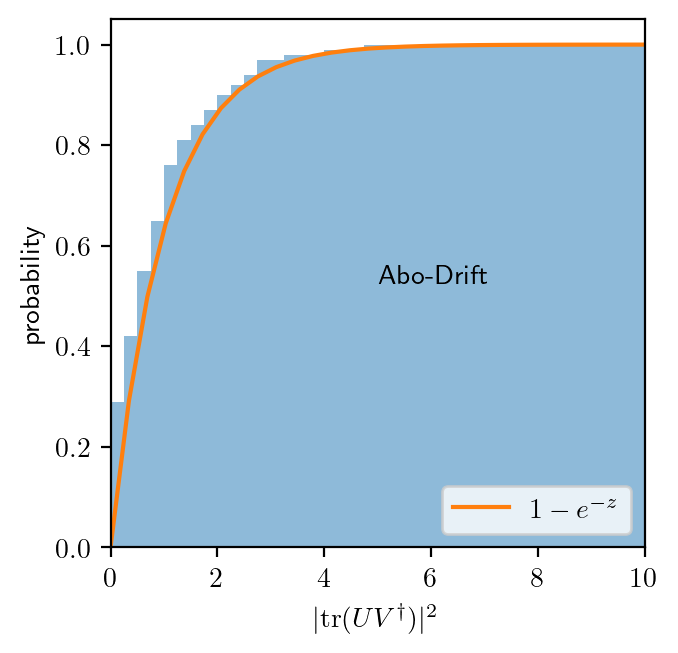

In [18]:
# compare with model by Abo I don't know what N to use!
N=41; N_u = 200  # dimension and number of Us in list 
twopi =2*np.pi
# base or fiducial values 
a0 = 2.5;     b0=0.0;       eps0=3.5;       mu0 = 2.0;     mup0 = 2.0;     tau0=0.0
a0_del = 1.0; b0_del = 0.0; eps0_del = 0.0; mu0_del = 0.0; mup0_del = 0.0; tau0_del = 0.0
db_min   = 0.0;   db_del = 0.0; 
dmu_min  = 0.1/twopi;  dmu_del = 0.9/twopi; 
dmup_min = 0.1/twopi; dmup_del = 0.9/twopi; 
nperiods = 5 

parms_abo = np.array([N,N_u,nperiods,a0,b0,eps0,mu0,mup0,tau0,db_min,dmu_min,dmup_min,a0_del,b0_del,eps0_del,mu0_del,mup0_del,tau0_del,db_del,dmu_del,dmup_del ])
#parms_adr =np.array([N,N_u,nperiods,a0,b0,eps0,mu0,mup0,tau0,db_min,dmu_min,dmup_min,a0_del,b0_del,eps0_del,mu0_del,mup0_del,tau0_del,db_del,dmu_del,dmup_del
#                      0 1   2       3  4  5   6    7    8    9      10       11     12       13      14     15      16       17       18      19      20
p_range(parms_abo)
Fvals_abo = rec_drift(parms_abo,seed=5)  # class of outputs, including values used,
plt_stuff1(Fvals_abo.zlist,'Abo-Drift','')

b at end 0.0  to  6.283185307179586
mu at end  2.3141592653589793  to  5.455751918948772
mup at end 2.3141592653589793  to  5.455751918948772
kone1 twosided pvalue=0.809
kone1 lower pvalue=0.555
kone1 greater pvalue=0.555
kone1 mean z =0.956 += 0.040, std z = 0.89
kone1 mean z2 =1.703 += 0.139, std z2 = 3.10



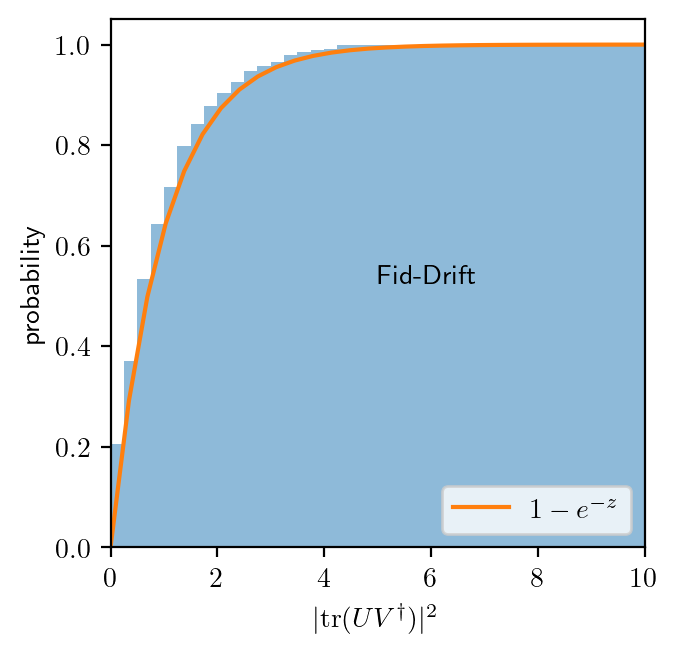

In [22]:
N=41; N_u = 1000  # dimension and number of Us in list 
# base or fiducial values 
a0 = 3.0;     b0=0.0;       eps0=3.01;        mu0 = 2.0;   mup0 = 2.0;      tau0=0.0
a0_del = 0.0; b0_del = 0.0; eps0_del = 0.0; mu0_del = 0.0; mup0_del = 0.0; tau0_del = 0.0
db_min   = 0.0;    db_del = 0.2; 
dmu_min  = 0.01;  dmu_del = 0.1; 
dmup_min = 0.01; dmup_del = 0.1; 
nperiods = 5 

parms_adr = np.array([N,N_u,nperiods,a0,b0,eps0,mu0,mup0,tau0,db_min,dmu_min,dmup_min,a0_del,b0_del,eps0_del,mu0_del,mup0_del,tau0_del,db_del,dmu_del,dmup_del ])
#parms_adr =np.array([N,N_u,nperiods,a0,b0,eps0,mu0,mup0,tau0,db_min,dmu_min,dmup_min,a0_del,b0_del,eps0_del,mu0_del,mup0_del,tau0_del,db_del,dmu_del,dmup_del
#                      0 1   2       3  4  5   6    7    8    9      10       11     12       13      14     15      16       17       18      19      20
p_range(parms_adr)
Fvals_adr = rec_drift(parms_adr,seed=15)  # class of outputs, including values used
plt_stuff1(Fvals_adr.zlist,'Fid-Drift','')


b at end 0.0  to  6.283185307179586
mu at end  2.3141592653589793  to  5.455751918948772
mup at end 2.3141592653589793  to  5.455751918948772
kone1 twosided pvalue=0.475
kone1 lower pvalue=0.241
kone1 greater pvalue=0.896
kone1 mean z =1.022 += 0.043, std z = 0.97
kone1 mean z2 =1.975 += 0.174, std z2 = 3.88



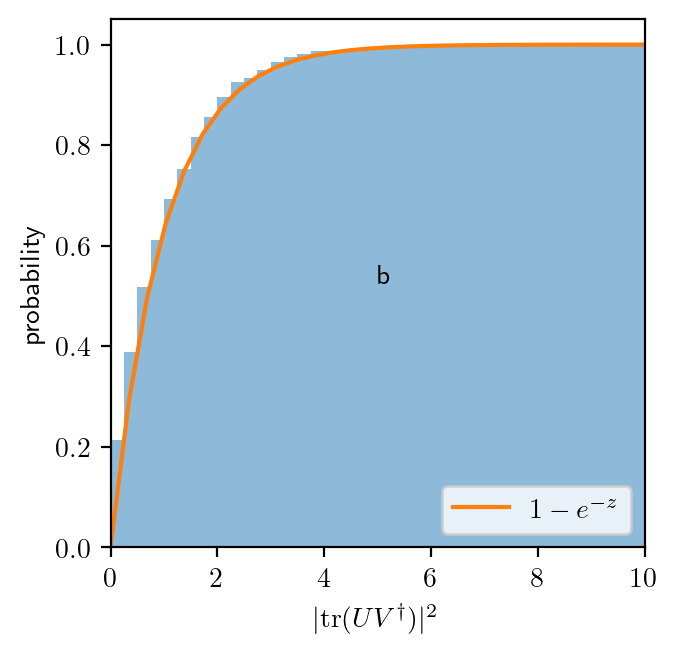

In [26]:
N=41; N_u = 1000  # dimension and number of Us in list 
# base or fiducial values 
a0 = 3.0;     b0=0.0;         eps0=3.01;        mu0 = 2.0;   mup0 = 2.0;      tau0=0.0
a0_del = 0.0; b0_del = twopi; eps0_del = 0.0; mu0_del = 0.0; mup0_del = 0.0; tau0_del = 0.0
db_min   = 0.0;    db_del = 0.0; 
dmu_min  = 0.01;  dmu_del = 0.1; 
dmup_min = 0.01; dmup_del = 0.1; 
nperiods = 5 

parms_adr_b = np.array([N,N_u,nperiods,a0,b0,eps0,mu0,mup0,tau0,db_min,dmu_min,dmup_min,a0_del,b0_del,eps0_del,mu0_del,mup0_del,tau0_del,db_del,dmu_del,dmup_del ])
#parms_adr =np.array([N,N_u,nperiods,a0,b0,eps0,mu0,mup0,tau0,db_min,dmu_min,dmup_min,a0_del,b0_del,eps0_del,mu0_del,mup0_del,tau0_del,db_del,dmu_del,dmup_del
#                      0 1   2       3  4  5   6    7    8    9      10       11     12       13      14     15      16       17       18      19      20
p_range(parms_adr_b)
Fvals_adr_b = rec_drift(parms_adr_b,seed=35)  # class of outputs, including values used
plt_stuff1(Fvals_adr_b.zlist,'b','')


In [ ]:
4*np.pi/3 